In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 04 consolidation — Symmetry preserves some things, not everything

Read `sessions/04_session.md` first. This is an executed reference, not an assessment of you.

**Evidence:** Real digit under exact array transformations; constructed matrices and annulus radii.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
import numpy as np

ROOT = Path.cwd().resolve()
while not (ROOT/'data/raw/iris.csv').is_file():
    if ROOT == ROOT.parent:
        raise FileNotFoundError('Start Jupyter in the extracted listening_to_shape_lab folder.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'src'))


## Step 1

Use two explicit matrices to demonstrate noncommutativity.

Before running: write your expected result and name one way this check could fail.

In [3]:
R90 = np.array([[0, -1], [1, 0]])
F = np.array([[-1, 0], [0, 1]])
p = np.array([1, 0])
print('R F p:', R90 @ F @ p, 'F R p:', F @ R90 @ p)
assert not np.array_equal(R90 @ F, F @ R90)

R F p: [ 0 -1] F R p: [0 1]


## Step 2

Apply the array action to a real digit. Preserve numerical invariants without assuming the label remains valid.

Before running: write your expected result and name one way this check could fail.

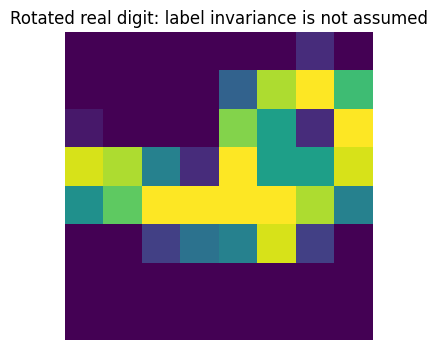

In [4]:
from shape_lab.data import digit_example
image, sample_id = digit_example(6)
rotated = np.rot90(image)
assert np.array_equal(np.rot90(image, 4), image)
assert image.sum() == rotated.sum()
assert np.array_equal(np.sort(image.ravel()), np.sort(rotated.ravel()))
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4)); plt.imshow(rotated)
plt.title('Rotated real digit: label invariance is not assumed'); plt.axis('off'); plt.show()

## Step 3

Numerically check the annulus radius formula for selected points; the text supplies the all-points argument.

Before running: write your expected result and name one way this check could fail.

In [5]:
radii = np.array([1., 1.5, 2.])
for t in [0., .25, .5, 1.]:
    moved = (1-t)*radii + t
    assert np.all((moved >= 1) & (moved <= 2))
result = {'sample_id': sample_id, 'rotation_order_test': 'passed',
          'label_preservation_claimed': False, 'annulus_check': 'selected radii; proof in text'}

## Keep execution evidence separate from learning evidence

The following saves this reference calculation. Write your own explanation in `my_work/`; no learner score is assigned.

In [6]:
result['stage'] = 4
result['execution_role'] = 'reference_consolidation'
result['data_role'] = 'Real digit under exact array transformations; constructed matrices and annulus radii.'
output = ROOT/'reports/consolidation_v4/04.json'
output.parent.mkdir(parents=True, exist_ok=True)
output.write_text(json.dumps(result, indent=2, allow_nan=False) + '\n')
print('Saved reference result:', output.relative_to(ROOT))


Saved reference result: reports/consolidation_v4/04.json
